<a href="https://colab.research.google.com/github/saranya7126/Student-Performance-Result-Analytics/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\nStudent Results\n
   StudentID    Name  Average Grade Pass/Fail
0          1    Arun     84.8     A      Pass
1          2    Bala     68.2     C      Pass
2          3  Charan     92.8    A+      Pass
3          4   Divya     50.0     D      Pass
4          5   Eswar     78.2     B      Pass
5          6   Farha     87.0     A      Pass
6          7   Gokul     38.4     F      Fail
7          8    Hari     91.2    A+      Pass
8          9   Indhu     59.6     D      Pass
9         10    Jaya     73.8     B      Pass
\nTopper:
Name       Charan
Average      92.8
Name: 2, dtype: object
\nWeak Students:
    Name  Average
6  Gokul     38.4
\nSubject-wise Average Marks:
Maths        71.0
Physics      72.5
Chemistry    73.6
English      72.8
Computer     72.1
dtype: float64
\nClass-wise Performance:
Class
CSE-A    79.900000
CSE-B    71.733333
CSE-C    63.066667
Name: Average, dtype: float64


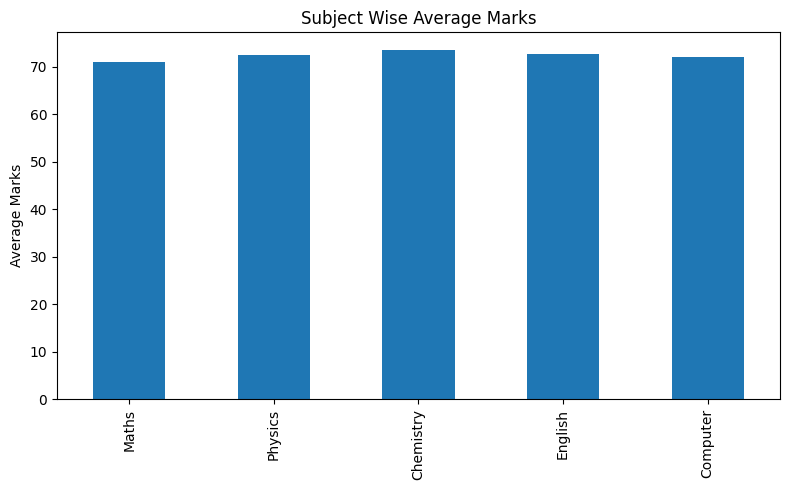

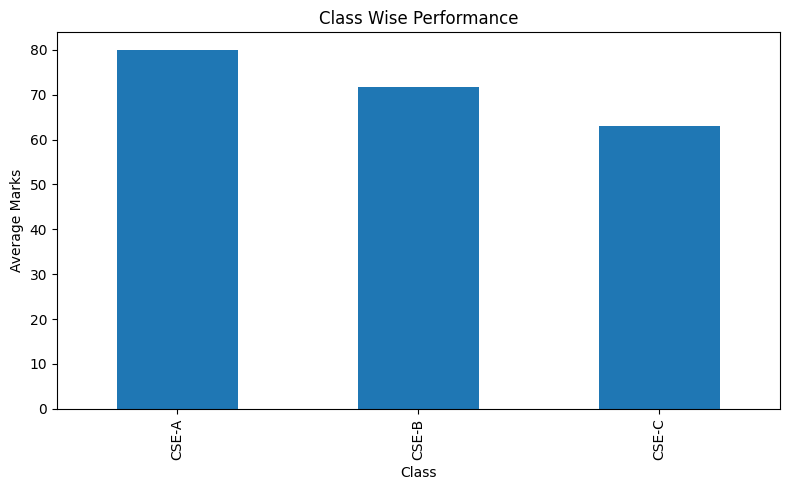

<Figure size 800x500 with 0 Axes>

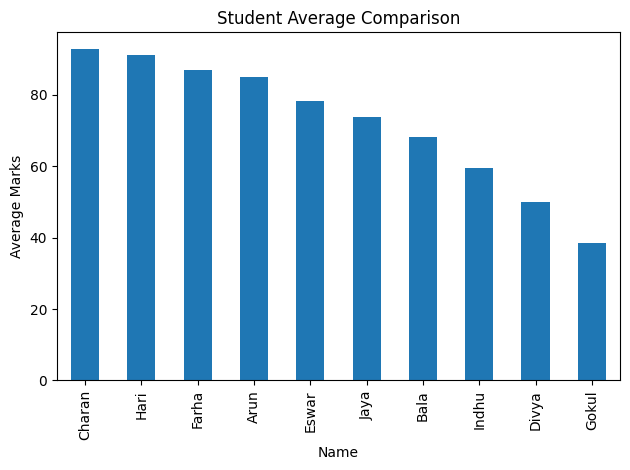

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("student_marks.csv")

subjects = ["Maths","Physics","Chemistry","English","Computer"]

df["Average"] = df[subjects].mean(axis=1)

def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)
df["Pass/Fail"] = df[subjects].apply(lambda x: "Pass" if (x >= 40).all() else "Fail", axis=1)

print("\\nStudent Results\\n")
print(df[["StudentID","Name","Average","Grade","Pass/Fail"]])

topper = df.loc[df["Average"].idxmax()]
print("\\nTopper:")
print(topper[["Name","Average"]])

weak_students = df[df["Pass/Fail"]=="Fail"]
print("\\nWeak Students:")
print(weak_students[["Name","Average"]])

subject_performance = df[subjects].mean()
print("\\nSubject-wise Average Marks:")
print(subject_performance)

class_performance = df.groupby("Class")["Average"].mean()
print("\\nClass-wise Performance:")
print(class_performance)

plt.figure(figsize=(8,5))
subject_performance.plot(kind="bar")
plt.title("Subject Wise Average Marks")
plt.ylabel("Average Marks")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
class_performance.plot(kind="bar")
plt.title("Class Wise Performance")
plt.ylabel("Average Marks")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
df.sort_values("Average", ascending=False).plot(
    x="Name", y="Average", kind="bar", legend=False
)
plt.title("Student Average Comparison")
plt.ylabel("Average Marks")
plt.tight_layout()
plt.show()